In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from helper.plot import plot_prof
from helper.diff_fit import diff_free, diff_global, diff_csglobal, diff_dglobal, diff_csfixed
from helper.diff_utils import diff_profile
import scipy
from scipy.optimize import curve_fit
from scipy.special import erfc

In [2]:
# ---- Loading data ----
import sys

if sys.platform == "win32": # windows
    depth_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_x.csv', dtype = float)
    time_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_time.csv', dtype = float)
    conc_df = pd.read_csv(r'C:\Users\t139116uhn\OneDrive - UHN\vis_test (caprese) results\vis_conc_xt.csv', dtype = float)

elif sys.platform == "darwin": # mac
    depth_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_x.csv', dtype = float)
    time_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_time.csv', dtype = float)
    conc_df = pd.read_csv('/Users/isaac/Library/CloudStorage/OneDrive-UHN/vis_test (caprese) results/vis_conc_xt.csv', dtype = float)

In [3]:
# convert to np arrayx
depth = np.asarray(depth_df, dtype = float).flatten()
time = np.asarray(time_df, dtype = float).flatten()
conc = np.asarray(conc_df, dtype = float)

# Normalizing profiles by baseline gel signal

In [9]:
import pydicom as dcm
import os

In [14]:
# ---- Loading data ----
if sys.platform == "win32": # windows
    dcm_dir = r"C:\Users\t139116uhn\OneDrive - UHN\Experiments\20260511 - VIS_1_test (caprese)\VIS_1_test"

elif sys.platform == "darwin": # mac
    dcm_dir = '/Users/isaac/Library/CloudStorage/OneDrive-UHN/Experiments/20260511 - VIS_1_test (caprese)/VIS_1_test'

In [15]:
# Get volume scan (gel scans without tracer)
names = os.listdir(dcm_dir)

paths = []

for name in names:
    if not name.lower().endswith(".dcm"):
        continue
    fullpath = os.path.join(dcm_dir, name)

    ds = dcm.dcmread(fullpath, stop_before_pixels = True)
    
    try:
        if ds.ScanOptions == "VOLUME_CT" and ds.SliceLocation == "+410.000":
            paths.append(fullpath)
    except:
        pass

KeyboardInterrupt: 

In [ ]:
# Converting baseline HU to concentration (implement with CALIB?)
baseline_ds = dcm.dcmread(paths[0])
spacing = baseline_ds.PixelSpacing
baseline_arr = getattr(baseline_ds, "pixel_array", None)
baseline_conc = (baseline_arr-16.08) / 16.655 # converting HU to conc (135 kVp)

baseline = baseline_conc[120:163, 182:212]

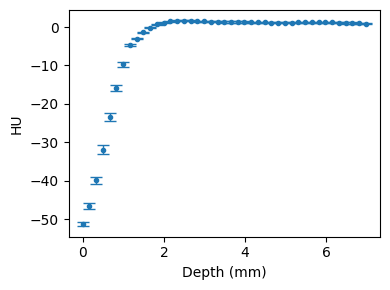

In [ ]:
rowmean = np.nanmean(baseline, axis = 1)
rowstd = np.nanstd(baseline, axis = 1)

fig, ax = plt.subplots(figsize = (4, 3))
ax.errorbar(np.arange(0, 43 * 0.166, 0.166), rowmean, yerr = rowstd, ms = 3, fmt = 'o',
            elinewidth = 1, capsize = 4)
ax.set_ylabel("HU")
ax.set_xlabel("Depth (mm)")
plt.tight_layout()
plt.show()

In [ ]:
baseline_norm = np.nanmean(baseline[10, :])

It seems that boundary of gel isn't a step function as expected. Partial volume effects? Gel surface not completely flat? Anyway, normalize row-by-row first then fit. Add additional variable x0.

Normalize by concentration in deep region first, then fit x0.

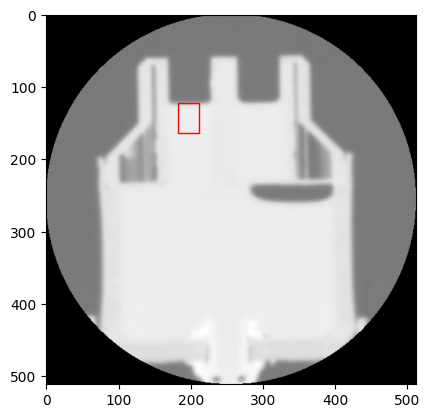

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots()
ax.imshow(baseline_arr, cmap = plt.cm.grey)
roi = patches.Rectangle(xy = (182, 122), width = 30, height = 41, color = "red", fill = False)
ax.add_patch(roi)
plt.show()

# Experimental Profile

In [16]:
conc_norm = conc - baseline_norm

NameError: name 'baseline_norm' is not defined

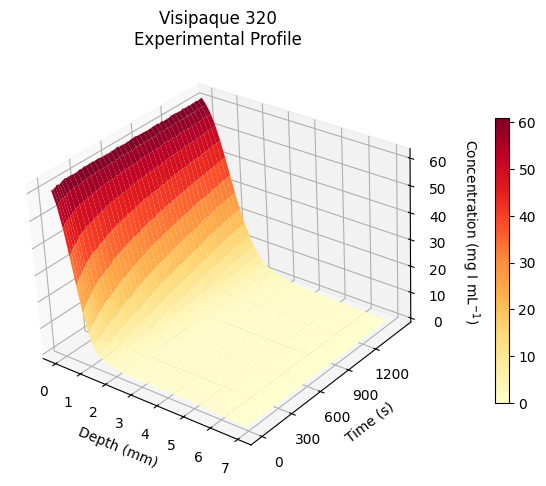

In [4]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc, 
          name = "Visipaque 320\nExperimental Profile", 
          elem = "I")
plt.tight_layout()
plt.show()

# Model Fitting
$$C(x,t) = C_s\cdot\operatorname{erfc}\left(\frac{x-x_0}{2\sqrt{Dt}}\right)$$

## 1. Free D and Cs

In [5]:
opt_free = diff_free(c_xt = conc, x = depth, time = time)

--------
Reporting Results
--------
t = 10.0 s: D = 3.186e-02, SE = 1.508e-03 (95% CI [2.881e-02, 3.490e-02]), Cs = 65.323, SE = 1.081 (95% CI [63.140, 67.507]), R2 = 0.9910, D-Cs corr = -0.572
t = 20.0 s: D = 1.668e-02, SE = 7.734e-04 (95% CI [1.512e-02, 1.824e-02]), Cs = 65.208, SE = 1.060 (95% CI [63.068, 67.348]), R2 = 0.9913, D-Cs corr = -0.574
t = 30.0 s: D = 1.118e-02, SE = 5.433e-04 (95% CI [1.008e-02, 1.228e-02]), Cs = 65.816, SE = 1.121 (95% CI [63.552, 68.080]), R2 = 0.9905, D-Cs corr = -0.574
t = 40.0 s: D = 8.651e-03, SE = 4.123e-04 (95% CI [7.819e-03, 9.484e-03]), Cs = 65.824, SE = 1.101 (95% CI [63.600, 68.047]), R2 = 0.9908, D-Cs corr = -0.575
t = 50.0 s: D = 7.006e-03, SE = 3.300e-04 (95% CI [6.339e-03, 7.672e-03]), Cs = 66.309, SE = 1.097 (95% CI [64.094, 68.524]), R2 = 0.9910, D-Cs corr = -0.575
t = 60.0 s: D = 5.986e-03, SE = 2.943e-04 (95% CI [5.392e-03, 6.580e-03]), Cs = 66.485, SE = 1.149 (95% CI [64.164, 68.806]), R2 = 0.9901, D-Cs corr = -0.576
t = 70.0 s: D = 

In [6]:
corrfree_per_t = opt_free['corr_per_t']
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]

print("--------")
print("D-Cs correlations per timepoint")
print("--------")
corr_summary = {}
pos_corr = {}

for t_idx in valid_idx:
    corr_t = corrfree_per_t[t_idx][0, 1]  # 2x2 matrix, D-Cs is [0,1]
    label = f"t={time[t_idx]}s"
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3:
        pos_corr[label] = corr_t

if not pos_corr:
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for label, val in pos_corr.items():
        print(f"  D vs Cs at {label}: {val:.3f}")

--------
D-Cs correlations per timepoint
--------
Moderate to strong correlations detected:
  D vs Cs at t=10.0s: -0.572
  D vs Cs at t=20.0s: -0.574
  D vs Cs at t=30.0s: -0.574
  D vs Cs at t=40.0s: -0.575
  D vs Cs at t=50.0s: -0.575
  D vs Cs at t=60.0s: -0.576
  D vs Cs at t=70.0s: -0.577
  D vs Cs at t=80.0s: -0.577
  D vs Cs at t=90.0s: -0.578
  D vs Cs at t=100.0s: -0.578
  D vs Cs at t=110.0s: -0.579
  D vs Cs at t=130.0s: -0.580
  D vs Cs at t=150.0s: -0.581
  D vs Cs at t=170.0s: -0.582
  D vs Cs at t=190.0s: -0.583
  D vs Cs at t=210.0s: -0.583
  D vs Cs at t=230.0s: -0.584
  D vs Cs at t=250.0s: -0.585
  D vs Cs at t=270.0s: -0.585
  D vs Cs at t=290.0s: -0.585
  D vs Cs at t=310.0s: -0.586
  D vs Cs at t=330.0s: -0.587
  D vs Cs at t=350.0s: -0.588
  D vs Cs at t=370.0s: -0.588
  D vs Cs at t=390.0s: -0.588
  D vs Cs at t=410.0s: -0.589
  D vs Cs at t=430.0s: -0.590
  D vs Cs at t=450.0s: -0.590
  D vs Cs at t=470.0s: -0.590
  D vs Cs at t=490.0s: -0.590
  D vs Cs at t=51

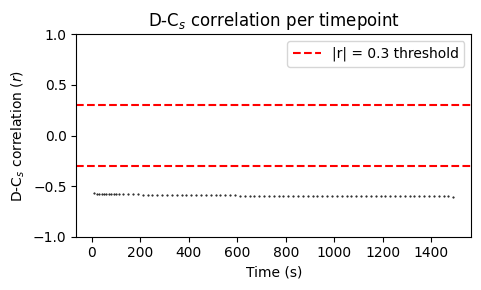

In [7]:
valid_idx = np.where(np.isfinite(opt_free["cs_per_t"]))[0]
dfree_csfree_corrs = [corrfree_per_t[i][0, 1] for i in valid_idx]
t_vals = [time[i] for i in valid_idx]

fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(t_vals, dfree_csfree_corrs,'o', ms = 0.5, mfc = 'k', mec = 'k')
ax.axhline(0.3, color='red', linestyle='--', label='|r| = 0.3 threshold')
ax.axhline(-0.3, color='red', linestyle='--')
ax.set_ylim(-1, 1)
ax.set_xlabel('Time (s)')
ax.set_ylabel(f'D-C$_s$ correlation ($r$)')
ax.set_title(f'D-C$_s$ correlation per timepoint')
ax.legend()
plt.tight_layout()
plt.show()

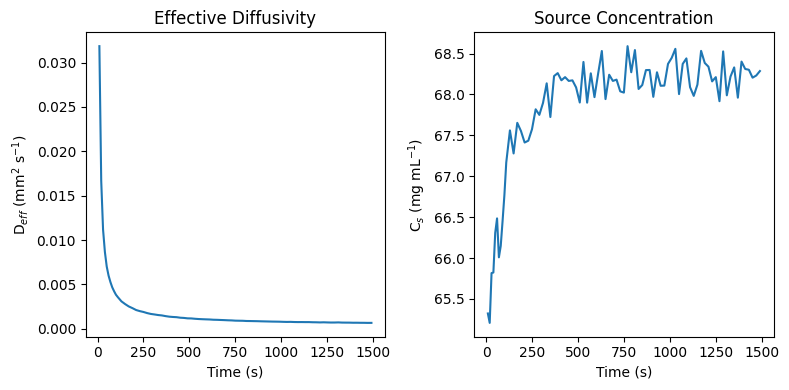

In [8]:
cs_free = opt_free['cs_per_t']
d_free = opt_free['d_per_t']

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))
ax[0].plot(time, d_free)
ax[0].set_title(f"Effective Diffusivity")
ax[0].set_ylabel(f'D$_{{eff}}$ (mm$^2$ s$^{{-1}}$)')
ax[0].set_xlabel('Time (s)')
ax[1].plot(time, cs_free)
ax[1].set_title("Source Concentration")
ax[1].set_ylabel(f'C$_s$ (mg mL$^{{-1}}$)')
ax[1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [9]:
np.nanmean(opt_free["r2_per_t"])

np.float64(0.9897587300026365)

In [9]:
from scipy.stats import skew, shapiro
mask = np.isnan(d_free)
print(f"Skew: {skew(d_free[~mask]):.3f}")
stat, p = shapiro(d_free[~mask])
print(f"Shapiro-Wilk p-value: {p}")

Skew: 5.266
Shapiro-Wilk p-value: 1.1350588989012617e-16


## 2. Fixed D and Free Cs

In [10]:
opt_dglobal = diff_dglobal(c_xt = conc, x = depth, time = time)


Global fit complete.
D = 1.083e-03 mm2/s, SE = 1.428e-05 (95%CI [1.055e-03, 1.111e-03]
Note: SE and CI are symmetric (curve_fit linear approximation)
t = 10.0 s: Cs = 71.171, SE = 4.228 (95%CI [62.881, 79.461])
t = 20.0 s: Cs = 75.575, SE = 4.001 (95%CI [67.731, 83.419])
t = 30.0 s: Cs = 77.698, SE = 3.826 (95%CI [70.196, 85.200])
t = 40.0 s: Cs = 78.536, SE = 3.689 (95%CI [71.303, 85.770])
t = 50.0 s: Cs = 79.304, SE = 3.577 (95%CI [72.290, 86.318])
t = 60.0 s: Cs = 79.539, SE = 3.483 (95%CI [72.710, 86.368])
t = 70.0 s: Cs = 78.890, SE = 3.402 (95%CI [72.220, 85.560])
t = 80.0 s: Cs = 78.731, SE = 3.330 (95%CI [72.202, 85.261])
t = 90.0 s: Cs = 78.817, SE = 3.267 (95%CI [72.412, 85.223])
t = 100.0 s: Cs = 78.771, SE = 3.210 (95%CI [72.477, 85.064])
t = 110.0 s: Cs = 78.903, SE = 3.158 (95%CI [72.710, 85.095])
t = 130.0 s: Cs = 78.563, SE = 3.067 (95%CI [72.548, 84.577])
t = 150.0 s: Cs = 77.556, SE = 2.990 (95%CI [71.694, 83.417])
t = 170.0 s: Cs = 77.198, SE = 2.922 (95%CI [71.469,

In [11]:
# Correlation coefficient calculation
dglobal_csfree_corr = opt_dglobal['corr']
valid_idx = np.where(np.isfinite(opt_dglobal["cs_per_t"]))[0]

param_labels = ['D'] + [f"Cs_t{i}" for i in valid_idx]

print("--------")
print("D correlations with each CS")
print("--------")

corr_summary = {}
pos_corr = {}

for i, label in enumerate(param_labels[1:]):
    corr_t = dglobal_csfree_corr[0, i + 1]
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3: 
        pos_corr[label] = corr_t

if not pos_corr: 
    print("Weak to no correlations detected.")
else:
    for key in pos_corr.keys():
        print("Moderate to strong correlations detected:")
        print(f"D vs {key}: {pos_corr[key]:.3f}")

--------
D correlations with each CS
--------
Weak to no correlations detected.


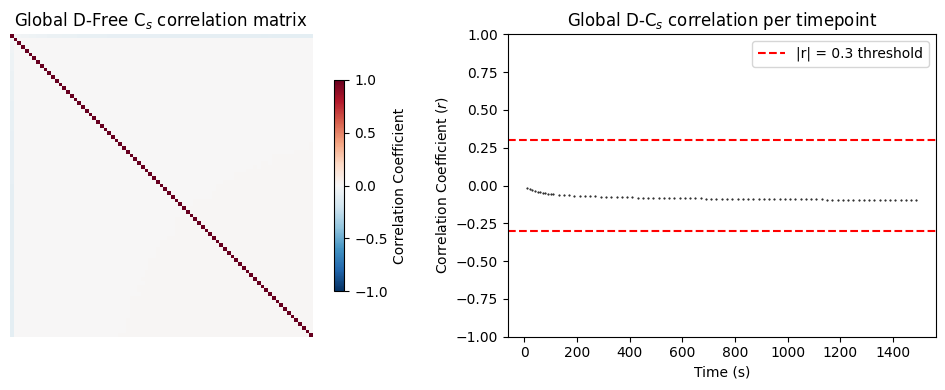

In [12]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (10, 4), gridspec_kw = {"width_ratios": [1, 1], "height_ratios": [1]})
# Correlation matrix
im = ax[0].imshow(dglobal_csfree_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax[0], label = "Correlation Coefficient", shrink = 0.7)
ax[0].set_title(f'Global D-Free C$_s$ correlation matrix')
ax[0].set_axis_off()

# Per-timepoint correlation (Global D vs. per-timepoint Cs)
t_vals = [time[i] for i in valid_idx]
ax[1].plot(t_vals, dglobal_csfree_corr[0, 1:], 'o', ms = 0.5, mfc = 'k', mec = 'k')
ax[1].set_ylim(-1, 1)
ax[1].axhline(y = -0.3, linestyle = "--", color = 'r')
ax[1].axhline(y = 0.3, linestyle = "--", color = 'r', label = '|r| = 0.3 threshold')
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(f"Correlation Coefficient ($r$)")
ax[1].set_title(f"Global D-C$_s$ correlation per timepoint")
ax[1].legend()
plt.tight_layout()
plt.show()

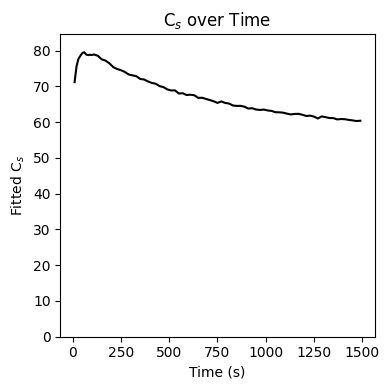

In [13]:
cs_opt = opt_dglobal['cs_per_t']

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot(time, cs_opt, color = 'k')
ax.set_ylim(0, (np.nanmax(cs_opt) + 5))
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Fitted C$_s$")
ax.set_ylim(0, np.nanmax(cs_opt) + 5)
ax.set_title(f"C$_s$ over Time")
plt.tight_layout()
plt.show()

## 3. Free D and Fixed Cs

In [14]:
opt_csglobal = diff_csglobal(c_xt = conc, x = depth, time = time)


Global fit complete.
Cs = 6.792e+01 mg/mL, SE = 1.306e-01 (95%CI [6.766e+01, 6.817e+01])
Note: SE and CI are symmetric (curve_fit linear approximation)
t = 10.0 s: D = 3.000e-02, SE = 1.399e-03 (95%CI [2.726e-02, 3.275e-02])
t = 20.0 s: D = 1.565e-02, SE = 7.219e-04 (95%CI [1.423e-02, 1.706e-02])
t = 30.0 s: D = 1.065e-02, SE = 4.888e-04 (95%CI [9.693e-03, 1.161e-02])
t = 40.0 s: D = 8.242e-03, SE = 3.753e-04 (95%CI [7.506e-03, 8.978e-03])
t = 50.0 s: D = 6.752e-03, SE = 3.057e-04 (95%CI [6.153e-03, 7.351e-03])
t = 60.0 s: D = 5.792e-03, SE = 2.603e-04 (95%CI [5.282e-03, 6.303e-03])
t = 70.0 s: D = 5.038e-03, SE = 2.256e-04 (95%CI [4.595e-03, 5.480e-03])
t = 80.0 s: D = 4.480e-03, SE = 1.998e-04 (95%CI [4.088e-03, 4.872e-03])
t = 90.0 s: D = 4.084e-03, SE = 1.810e-04 (95%CI [3.729e-03, 4.439e-03])
t = 100.0 s: D = 3.737e-03, SE = 1.650e-04 (95%CI [3.414e-03, 4.061e-03])
t = 110.0 s: D = 3.508e-03, SE = 1.536e-04 (95%CI [3.207e-03, 3.809e-03])
t = 130.0 s: D = 3.058e-03, SE = 1.329e-04

In [15]:
# Correlation coefficient calculation
dfree_csglobal_corr = opt_csglobal['corr']
valid_idx = np.where(np.isfinite(opt_csglobal["d_per_t"]))[0]

param_labels = ['Cs'] + [f"D_t{i}" for i in valid_idx]

print("--------")
print("D correlations with each CS")
print("--------")

corr_summary = {}
pos_corr = {}

for i, label in enumerate(param_labels[1:]):
    corr_t = dfree_csglobal_corr[0, i + 1]
    corr_summary[label] = corr_t
    if abs(corr_t) >= 0.3: 
        pos_corr[label] = corr_t

if not pos_corr: 
    print("Weak to no correlations detected.")
else:
    print("Moderate to strong correlations detected:")
    for key in pos_corr.keys():
        print(f"D vs {key}: {pos_corr[key]:.3f}")

--------
D correlations with each CS
--------
Weak to no correlations detected.


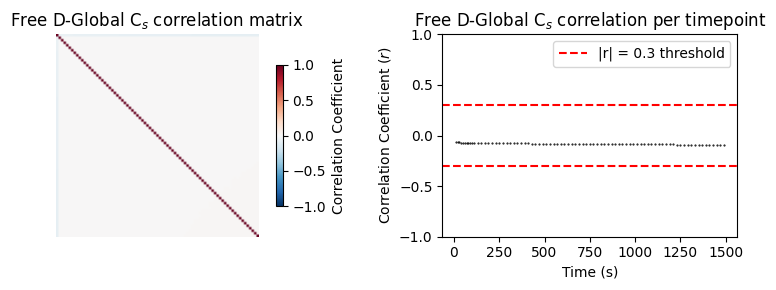

In [16]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize = (8, 3), gridspec_kw = {"width_ratios": [1.2, 1], "height_ratios": [1]})
# Correlation matrix
im = ax[0].imshow(dfree_csglobal_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax[0], label = "Correlation Coefficient", shrink = 0.7)
ax[0].set_title(f'Free D-Global C$_s$ correlation matrix')
ax[0].set_axis_off()

# Per-timepoint correlation (Global D vs. per-timepoint Cs)
t_vals = [time[i] for i in valid_idx]
ax[1].plot(t_vals, dfree_csglobal_corr[0, 1:], 'o', ms = 0.5, mfc = 'k', mec = 'k')
ax[1].set_ylim(-1, 1)
ax[1].axhline(y = -0.3, linestyle = "--", color = 'r')
ax[1].axhline(y = 0.3, linestyle = "--", color = 'r', label = '|r| = 0.3 threshold')
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel(f"Correlation Coefficient ($r$)")
ax[1].set_title(f"Free D-Global C$_s$ correlation per timepoint")
ax[1].legend()
plt.tight_layout()
plt.show()

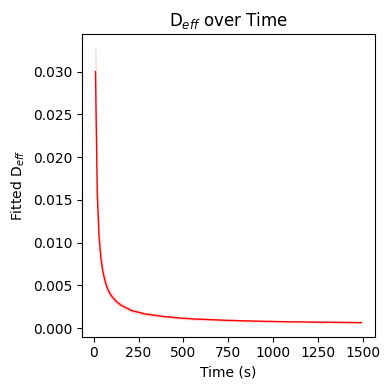

In [17]:
d_opt = opt_csglobal['d_per_t']
d_lb = opt_csglobal['lb_all']
d_ub = opt_csglobal['ub_all']

d_opt[0] = np.nan
d_lb[0] = np.nan
d_ub[0] = np.nan

fig, ax = plt.subplots(figsize = (4, 4))
ax.plot(time, d_opt, color = 'r', lw = 1)
ax.fill_between(time,
               d_lb, d_ub,
               color = 'red',
               alpha = 0.1)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Fitted D$_{{eff}}$")
ax.set_title(f"D$_{{eff}}$ over Time")
plt.tight_layout()
plt.show()

## 4. Fixed D and Cs

In [18]:
opt_global = diff_global(c_xt = conc, x = depth, time = time)


Global fit complete.
D = 1.022e-03, Cs = 6.677e+01 mg/mL, SE = 3.312e-01 (95%CI [6.612e+01, 6.742e+01]
Note: SE and CI are symmetric (curve_fit linear approximation)
Mean per-timepoint R2 = 0.9217

Correlation matrix:
                  Cs         D
        Cs 1.000e+00-5.903e-01
         D-5.903e-01 1.000e+00


In [20]:
opt_global["se_d"]

np.float64(1.4097673567218291e-05)

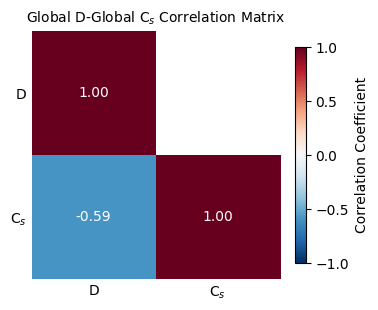

In [84]:
# Plotting correlation matrix
dglobal_csglobal_corr = opt_global['corr']
labels = ["D", f"C$_s$"]

# Mask upper triangle
mask = np.triu(np.ones_like(dglobal_csglobal_corr, dtype = bool), k = 1)

# Apply mask
masked_corr = np.ma.masked_where(mask, dglobal_csglobal_corr)

fig, ax = plt.subplots(figsize = (4, 4))
im = ax.imshow(masked_corr, vmin = -1, vmax = 1, cmap = plt.cm.RdBu_r)
fig.colorbar(im, ax = ax, label = 'Correlation Coefficient', shrink = 0.7)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.tick_params(length = 0)

# add values to cells
for i in range(masked_corr.shape[0]):
    for j in range(masked_corr.shape[1]):
        if not mask[i, j]:
            ax.text(
                j, i,
                f"{dglobal_csglobal_corr[i, j]:.2f}",
                ha = 'center',
                va = 'center',
                color = 'white'
            )

# Remove border box
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f"Global D-Global C$_s$ Correlation Matrix", fontdict = {"size": 10})
plt.show()

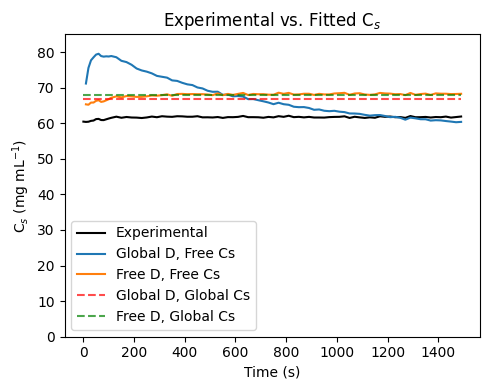

In [31]:
# Cs values
first_row = conc[:, 0] # experimental
cs_dfixed = opt_dglobal['cs_per_t']
cs_dfree = opt_csglobal['cs_global']
cs_free = opt_free['cs_per_t']
cs_glob = opt_global['cs_global']

fig, ax = plt.subplots(figsize = (5, 4))
ax.plot(time, first_row, label = 'Experimental', color = 'k')
ax.plot(time, cs_dfixed, label = 'Global D, Free Cs')
ax.plot(time, cs_free, label = 'Free D, Free Cs')
ax.hlines(y = cs_glob, xmin = np.nanmin(time), xmax = np.nanmax(time), 
          label = 'Global D, Global Cs', 
          color = 'red', linestyle = '--', alpha = 0.7)
ax.hlines(y = cs_dfree, xmin = np.nanmin(time), xmax = np.nanmax(time), 
          label = 'Free D, Global Cs', 
          color = 'green', linestyle = '--', alpha = 0.7)
ax.legend()
ax.set_ylim(0, 85)
ax.set_title(f"Experimental vs. Fitted C$_s$")
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"C$_s$ (mg mL$^{{-1}})$")

plt.tight_layout()
plt.show()

# Sensitivity Analyses

## 1. Fixing Cs to experimental Cs 
- Cs is consistently overestimated when compared to *experimental* Cs
- Negative correlation in most fittings - Cs overestimated and D underestimated
- May be due to profile in earlier timepoints being too steep -> unable to fit properly
- Due to these, D is not actually time-varying, but constant.

In [33]:
# Mean experimental Cs
mean_exp_cs = np.nanmean(first_row)
res_mean_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = mean_exp_cs
)

# Per-timepoint experimental CS
exp_cs = first_row
res_per_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = exp_cs)



Global D fit complete.
D = 1.159e-03, SE = 1.404e-05 (95%CI [1.132e-03, 1.187e-03]
Mean per-timepoint R2 = 0.9173

Per-timepoint D fit:
t = 10.0 s: Cs = 61.625, D = 3.478e-02, SE = 1.577e-03 (95% CI[3.160e-02, 3.797e-02]), R2 = 0.9883
t = 20.0 s: Cs = 61.625, D = 1.819e-02, SE = 8.027e-04 (95% CI[1.657e-02, 1.981e-02]), R2 = 0.9888
t = 30.0 s: Cs = 61.625, D = 1.234e-02, SE = 5.893e-04 (95% CI[1.115e-02, 1.353e-02]), R2 = 0.9871
t = 40.0 s: Cs = 61.625, D = 9.562e-03, SE = 4.493e-04 (95% CI[8.655e-03, 1.047e-02]), R2 = 0.9874
t = 50.0 s: Cs = 61.625, D = 7.822e-03, SE = 3.776e-04 (95% CI[7.060e-03, 8.584e-03]), R2 = 0.9868
t = 60.0 s: Cs = 61.625, D = 6.716e-03, SE = 3.375e-04 (95% CI[6.035e-03, 7.397e-03]), R2 = 0.9856
t = 70.0 s: Cs = 61.625, D = 5.843e-03, SE = 2.756e-04 (95% CI[5.287e-03, 6.400e-03]), R2 = 0.9872
t = 80.0 s: Cs = 61.625, D = 5.192e-03, SE = 2.487e-04 (95% CI[4.690e-03, 5.693e-03]), R2 = 0.9868
t = 90.0 s: Cs = 61.625, D = 4.734e-03, SE = 2.328e-04 (95% CI[4.264e-0

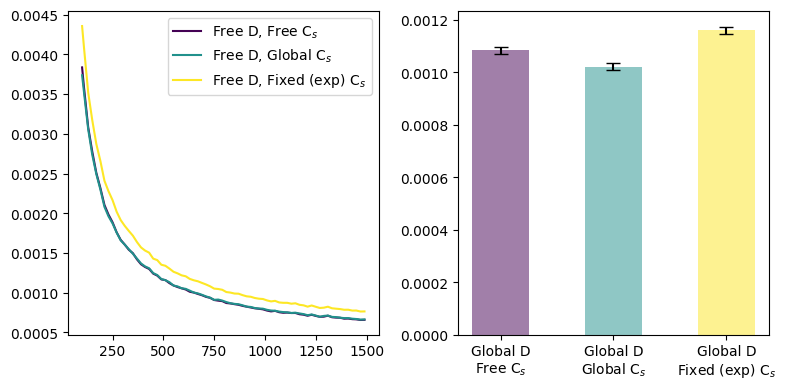

In [34]:
# ---- Plotting ----
# -- Fixed D --
dglob_cfree = opt_dglobal['d_global']
dglob_cglob = opt_global['d_global']
dglob_cfixedm = res_mean_cs['d_global']
# - Errors - 
dgcf_sem = opt_dglobal['se_d']
dgcg_sem = opt_global['se_d']
dgcfm_sem = res_mean_cs['se_d_global']

# -- Per-timepoint D --
dfree_cfree = opt_free['d_per_t']
dfree_cglob = opt_csglobal['d_per_t']
dfree_cfixed = res_per_cs['d_per_t']

# -- Plot --
fig, ax = plt.subplots(1, 2, figsize = (8, 4))

cmap = plt.get_cmap('viridis')
n_fits = 3
x_pos = np.arange(n_fits)
colors = cmap(np.linspace(0, 1, n_fits))

fd = ax[0] # global d
gd = ax[1] # free d

dfcf = fd.plot(time[10:], dfree_cfree[10:],
       label = 'Free D, Free C$_s$',
              color = colors[0])
dfcg = fd.plot(time[10:], dfree_cglob[10:],
       label = 'Free D, Global C$_s$',
              color = colors[1])
dfcfixed = fd.plot(time[10:], dfree_cfixed[10:],
       label = 'Free D, Fixed (exp) C$_s$',
                  color = colors[2])
fd.legend()

gd.bar(x_pos,
       [dglob_cfree,
       dglob_cglob,
       dglob_cfixedm],
       yerr = [dgcf_sem, dgcg_sem, dgcfm_sem],
       color = colors,
      alpha = 0.5,
      capsize = 5,
      width = 0.5)
gd.set_xticks(x_pos)
gd.set_xticklabels([f"Global D\nFree C$_s$",
                   f"Global D\nGlobal C$_s$",
                   f"Global D\nFixed (exp) C$_s$"])

plt.tight_layout()
plt.show()

## 2. Shifting `valid_indices` to identify informative timepoints
- From (1), earlier timepoints give an unstable fitting of D and may introduce bias
- Excluding uninformative timepoints may give a more precise fitting of D
> **Objective**: See whether shifting `valid_indices` (fitted timepoints) would eventually lead to a stabilized fitted D

In [35]:
# --- Loading variables ---
# Per-timepoint experimental CS
exp_cs = first_row
res_per_cs = diff_csfixed(
    c_xt = conc, x = depth, time = time,
    cs_fixed = exp_cs, print_res = False)

In [36]:
# --- Varying timepoint to fit ---
idx_list = []

start_idx = 1
end = len(time)
for i in range(len(time)):
    indices = np.arange(start_idx, end)
    idx_list += [indices]
    if time[start_idx] < 130:
        start_idx += 6
    elif time[start_idx] > 130 and start_idx < end - 6:
        start_idx += 3
    else:
        break

In [37]:
# iterating through each list of indices
varidx_d = []
varidx_d_se = []
varidx_d_lb = []
varidx_d_ub = []
varidx_r2 = [] # global r2

for idx in idx_list:
    opt = diff_csfixed(
        c_xt = conc, x = depth, time = time,
        fit_indices = idx,
        cs_fixed = exp_cs, print_res = False
    )
    varidx_d += [opt["d_global"]]
    varidx_d_se += [opt["se_d_global"]]
    varidx_d_lb += [opt["lb_d_global"]]
    varidx_d_ub += [opt["ub_d_global"]]
    varidx_r2 += [opt["r2_global"]]

In [38]:
# ---- Preparing for plotting ----
first_idx = [list[0] for list in idx_list]
first_time = [time[i] for i in first_idx]

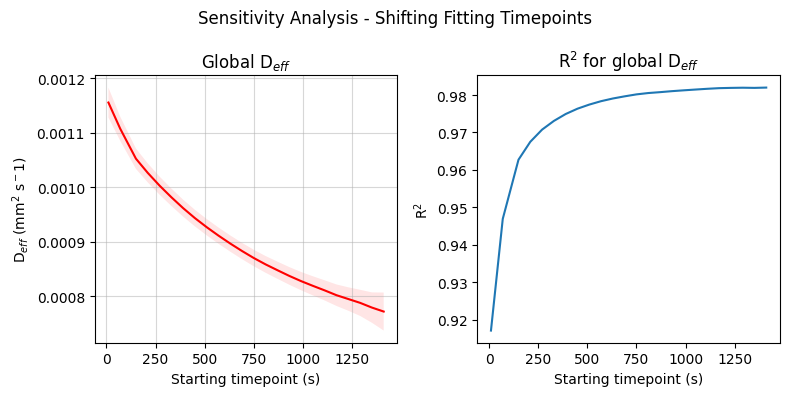

In [39]:
# ---- Plotting ----
fig, ax = plt.subplots(1, 2, figsize = (8, 4))
ax[0].plot(first_time, varidx_d, color = 'r')
ax[0].fill_between(first_time, 
                   varidx_d_lb, varidx_d_ub,
                   facecolor = 'red',
                   alpha = 0.1)
ax[0].grid(alpha = 0.5)
ax[0].set_title(f"Global D$_{{eff}}$")
ax[0].set_xlabel("Starting timepoint (s)")
ax[0].set_ylabel(f"D$_{{eff}}$ (mm$^2$ s$^{-1}$)")
ax[1].plot(first_time, varidx_r2)
ax[1].set_xlabel("Starting timepoint (s)")
ax[1].set_ylabel("R$^2$")
ax[1].set_title(f"R$^2$ for global D$_{{eff}}$")
fig.suptitle("Sensitivity Analysis - Shifting Fitting Timepoints")
plt.tight_layout()
plt.show()

Fitted global $D$ values not stabilizing.

In [ ]:
import pandas as pd

dat = {"starting timepoint": first_time,
       "global_d": varidx_d,
       "global_d_se": varidx_d_se}

df = pd.DataFrame(dat)

## 3. Fitting the asymptote to 1 and 2
Note that the per-timepoint D fittings (free D) all undergo negative exponential decay, and that shifting the timepoint also seems to give a similar result. Exponential decay can be fitted with the following equation
$$D_t = D_{\infty}+Ae^{-\lambda t}$$
&emsp; where $D_t$ is a diffusivity at time $t$, $D_{\infty}$ is diffusivity at $t=\infty$, $A$ is the initial offset above the asmptote, and $\lambda$ the rate constant of decay. 

At early timepoints, contrast had not penetrated sufficiently deep into the gel to allow for a reliable fitting of the concentration profile (too steep), resulting in overestimated diffusivity values. At later timepoints, the profile is more developed and we can see a gradual stabilizing of D. Therefore, it is hypothesized that the asymptotic D value $D_\infty$ is the consistent D fitting. 

In [40]:
def exp_decay(t, D_inf, A, lam): # exponential decay model
    return D_inf + A * np.exp(-lam * t)

In [41]:
from scipy.optimize import curve_fit

def fit_decay(D_per_t, time, sem):
    # ---Masking infs and NaNs---
    mask = np.isfinite(D_per_t) & np.isfinite(time) & np.isfinite(sem)
    D_clean = D_per_t[mask]
    time_clean = time[mask]
    sem_clean = sem[mask]

    # ---Initial guesses based on data---
    p0 = [D_clean[-1], D_clean[0] - D_clean[-1], 200]

    # ---Bounds---
    bounds = (
        [0, 0, 0],
        [1e-1, 1, 10000]
    )

    # ---Fitting---
    popt, pcov = curve_fit(exp_decay, time_clean, D_clean,
                           p0 = p0,
                           bounds = bounds,
                           sigma = sem_clean,
                           absolute_sigma = True)
    
    D_inf, A, lam = popt
    D_inf_se = np.sqrt(pcov[0, 0])

    output = {"d_inf": D_inf,
              "A": A,
              "lambda": lam,
              "d_inf_se": D_inf_se}
    
    print(f"D_inf = {D_inf:.3e} mm2/s; SE = {D_inf_se:.3e}")
    
    return output

In [42]:
print(res_mean_cs['d_per_t'])

[       nan 0.03478474 0.01818548 0.01234383 0.00956169 0.00782232
 0.00671565 0.00584344 0.00519152 0.00473386 0.00432607 0.00405848
 0.00353912 0.00316664 0.00288192 0.00265785 0.00240686 0.00226856
 0.00216457 0.00203203 0.00191694 0.00185583 0.00178685 0.00172467
 0.00165096 0.00158103 0.00153724 0.00151092 0.00144033 0.00141078
 0.00135317 0.00133828 0.00130648 0.00125926 0.00124567 0.00122006
 0.00121086 0.00118514 0.00115781 0.00114527 0.00112417 0.00110101
 0.00108416 0.00105151 0.00105503 0.00104032 0.00101933 0.00100308
 0.00099302 0.00098732 0.00097244 0.00095346 0.000948   0.00093204
 0.00092599 0.00092338 0.0009062  0.00089676 0.0008936  0.00088072
 0.00087251 0.00086923 0.0008616  0.00086423 0.00085371 0.00084399
 0.00082879 0.00083982 0.00082439 0.00080474 0.00081853 0.00082411
 0.00080473 0.00080091 0.00079296 0.00078686 0.00078655 0.00077876
 0.00077404 0.00076462 0.00076853]


In [43]:
print(time)

[   0.   10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.
  130.  150.  170.  190.  210.  230.  250.  270.  290.  310.  330.  350.
  370.  390.  410.  430.  450.  470.  490.  510.  530.  550.  570.  590.
  610.  630.  650.  670.  690.  710.  730.  750.  770.  790.  810.  830.
  850.  870.  890.  910.  930.  950.  970.  990. 1010. 1030. 1050. 1070.
 1090. 1110. 1130. 1150. 1170. 1190. 1210. 1230. 1250. 1270. 1290. 1310.
 1330. 1350. 1370. 1390. 1410. 1430. 1450. 1470. 1490.]


In [44]:
# ---Fitting---
print("----Asymptotes (D_inf)----")
print("--Free D, Free Cs--")
asymptote_dfcf = fit_decay(opt_free["d_per_t"], time, opt_free["se_d_per_t"])
print("")
print("--Free D, Global Cs--")
asymptote_dfcg = fit_decay(opt_csglobal["d_per_t"], time, opt_csglobal["se_d_per_t"])
print("")
print("--Free D, Fixed Cs--")
asymptote_dfcfixed = fit_decay(res_mean_cs["d_per_t"], time, res_mean_cs["se_d_per_t"])
print("")
print("--Shifting timepoints--")
asymptote_shift = fit_decay(np.asarray(varidx_d), np.asarray(first_time), np.asarray(varidx_d_se))

----Asymptotes (D_inf)----
--Free D, Free Cs--
D_inf = 8.510e-04 mm2/s; SE = 5.050e-06

--Free D, Global Cs--
D_inf = 8.462e-04 mm2/s; SE = 3.947e-06

--Free D, Fixed Cs--
D_inf = 1.005e-03 mm2/s; SE = 6.709e-06

--Shifting timepoints--
D_inf = 9.042e-04 mm2/s; SE = 1.826e-06


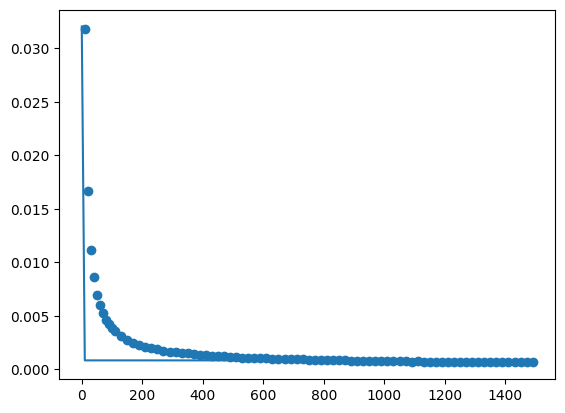

In [45]:
fig, ax = plt.subplots()
ax.scatter(time, opt_free['d_per_t'])
ax.plot(time, exp_decay(time, asymptote_dfcf["d_inf"], asymptote_dfcf["A"], asymptote_dfcf["lambda"]))

In [46]:
d_inf = asymptote_shift["d_inf"]
a = asymptote_shift["A"]
lam = asymptote_shift["lambda"]

In [47]:
for t, d in zip(first_time[:10], opt_free["d_per_t"][:10]):
    print(f"t = {t:.1f}s, D = {d:.3e}")

t = 10.0s, D = nan
t = 70.0s, D = 3.186e-02
t = 150.0s, D = 1.668e-02
t = 210.0s, D = 1.118e-02
t = 270.0s, D = 8.651e-03
t = 330.0s, D = 7.006e-03
t = 390.0s, D = 5.986e-03
t = 450.0s, D = 5.265e-03
t = 510.0s, D = 4.666e-03
t = 570.0s, D = 4.224e-03


In [48]:
print(d_inf)
print(a)
print(lam)

0.0009041708463442554
0.00038333618023610584
200.0


In [ ]:
plot_shift = exp_decay(np.asarray(first_time), d_inf, a, lam)

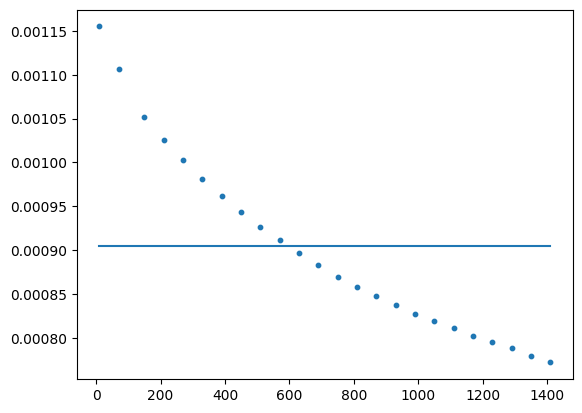

In [ ]:
fig, ax = plt.subplots()
ax.scatter(first_time, varidx_d, s = 10, label = "data")
ax.plot(first_time, plot_shift)

## 4. Boltzmann-Matano Analysis
Given that shifting timepoints and adjusting ROI sizes do not reasonably stabilize the fitted D values, alternate methods of analyses may be needed. An unstable D fitting signifies potential violations of the initial or boundary conditions described earlier, though this is not supported by our experimental data. Instead, one might consider that diffusivity is not constant but rather concentration-, depth-, or time-dependent. 

To see whether diffusivity is concentration-dependent, the Boltzmann-Matano method can be employed. In short, the Boltzmann variable ($\eta=\frac{x}{2\sqrt{t}}$) can be substituted into Fick's second law to give a simpler ordinary differential equation.

$$\begin{align}
\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}\Rightarrow-2\eta\frac{dC}{d\eta}=\frac{d}{d\eta}\left(D\frac{dC}{d\eta}\right) \tag{1}
\end{align}$$

Integrating with respect to $\eta$ gives the solution
$$-2\int^{C_1}_0\eta\,dC=\left[D\frac{dC}{d\eta}\right]^{C=C_1}_{C=0}$$
As $D\frac{dC}{d\eta}=0$ when $C=0$, the solution simplifies to
$$-2\int^{C_1}_0\eta\,dC=\left(D\frac{dC}{d\eta}\right)_{C=C_1}$$
Rearranging the equation and reintroducing $x$ and $t$, we obtain
$$D_{C=C_1}=-\frac{1}{2t}\frac{dx}{dC}\int^{C_1}_0x\,dC \tag{2}$$



> As an initial check to see if Boltzmann-Matano is valid, plotting concentration vs. Boltzmann variable.

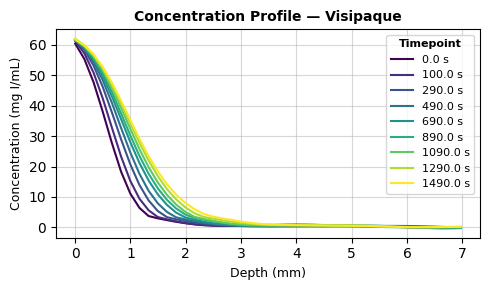

In [49]:
# ---- Experimental concentration profiles at the beginning, middle, and end of the experiment ----
profs = range(0, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(figsize = (5, 3))
j = 0
for i in profs:
    ax.plot(depth, conc[i, :], label = f"{time[i]} s", color = colors[j])
    j += 1
ax.legend(title = "Timepoint", fontsize = 8, 
          title_fontproperties = {"weight": "bold", "size": 8})
ax.set_ylabel("Concentration (mg I/mL)", size = 9)
ax.set_xlabel("Depth (mm)", size = 9)
ax.grid(alpha = 0.5)
ax.set_title(f"Concentration Profile — Visipaque", 
             fontdict = {"weight": "bold", "size": 10})
plt.tight_layout()
plt.show()

Profile at latest timepoints bottoms out at ~4mm. Additional 3mm will skew the $D(C)$ fitting as a small increase in concentration will lead to large fluctuations in $dx/dc$. Add automatic cut-off to remove skew.

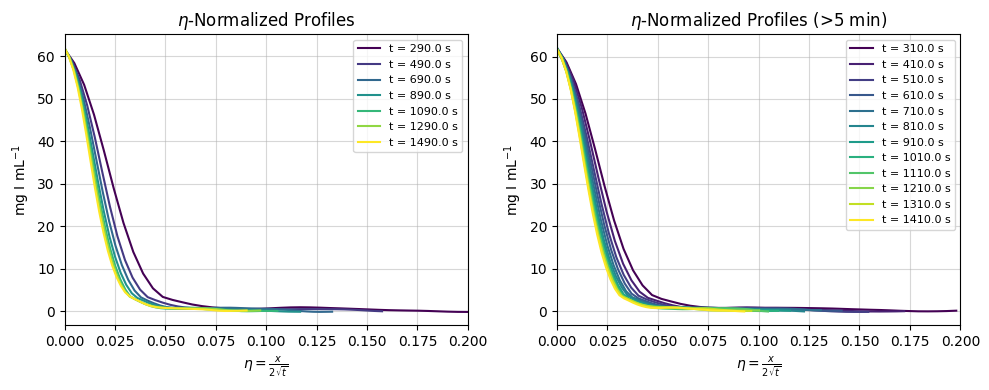

In [50]:
# Initial check to see if Boltzmann-Matano is valid (i.e., Profiles overlap)
profs = range(20, len(time), 10)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 4))

# Plotting all timepoints
for i, prof in enumerate(profs):
    eta = depth / (2 * np.sqrt(time[prof]))
    ax[0].plot(eta, conc[prof, :], label = f"t = {time[prof]} s", color = colors[i])

ax[0].set_xlabel(f"$\\eta = \\frac{{x}}{{2\\sqrt{{t}}}}$")
ax[0].set_ylabel(f"mg I mL$^{{-1}}$")
ax[0].set_xlim(0, 0.2)
ax[0].set_title(f"$\\eta$-Normalized Profiles")
ax[0].grid(alpha = 0.5)
ax[0].legend(fontsize = 8)

# Plotting timepoints beyond 5 min
profs = range(21, len(time), 5)
n_profs = len(profs)
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, n_profs))
for i, prof in enumerate(profs):
    eta = depth / (2 * np.sqrt(time[prof]))
    ax[1].plot(eta, conc[prof, :], label = f"t = {time[prof]} s", color = colors[i])

ax[1].set_xlabel(f"$\\eta = \\frac{{x}}{{2\\sqrt{{t}}}}$")
ax[1].set_ylabel(f"mg I mL$^{{-1}}$")
ax[1].set_xlim(0, 0.2)
ax[1].set_title(f"$\\eta$-Normalized Profiles (>5 min)")
ax[1].grid(alpha = 0.5)
ax[1].legend(fontsize = 8)

plt.tight_layout()
plt.show()

Profiles start overlapping towards later timepoints. Boltzmann-Matano analysis will be applied to each timepoint but later timepoints might be more informative. The workflow for one profile (timepoints) is as follows:
1. Integrate w.r.t. concentration ($y$-axis) and find Matano interface $x=0$ where $\int^{{C\infty}}_0 x\,dC$ = 0
2. For each concentration value in the profile:\
&emsp; a. Compute integral $\int^{{C\ast}}_{{C_0}}x\,dC$ numerically\
&emsp; b. Compute slope $\frac{{dC}}{{dx}}$ at $C=C^{{\ast}}$ numerically\
&emsp; c. Divide to get $D(C^{{\ast}}$)
3. Plot D vs C to see how diffusivity varies with concentration

In [51]:
def diff_bm(prof, x, time):
    """
    """
    # ----Step 0: Find cutoff and filter to remove uninformative depths----
    prof_min = np.nanmin(prof)
    prof_max = np.nanmax(prof)

    # Set threshold within 5% of baseline (change p as needed)
    p = 0.05 
    threshold = prof_min + p * (prof_max - prof_min)

    # Find last index where concentration is above threshold
    cutoff_idx = np.where(prof > threshold)[0][-1]
    x_trimmed = x[:cutoff_idx]
    prof_trimmed = prof[:cutoff_idx]


    # ----Step 1: Find Matano interface----
    depth = x_trimmed
    trap_areas = np.diff(prof_trimmed) * (depth[:-1] + depth[1:]) / 2 # trapezoidal rule for every delta C and delta x
    cumulative = np.concatenate([[0], np.cumsum(trap_areas)]) # adding all trapezoidal areas together
    total = cumulative[-1] # total integral
    matano_idx = np.argmin(np.abs(cumulative - total / 2))
    x_M = depth[matano_idx] # x pos of Matano plane
    depth_shifted = depth - x_M # shifting depth

    print(x_M)

    # ----Step 2: Compute D at each concentration----
    trap_areas_shifted = np.diff(prof_trimmed) * (depth_shifted[:-1] + depth_shifted[1:]) / 2
    cumulative_shifted = np.concatenate([[0], np.cumsum(trap_areas_shifted)]) # integral
    slopes_shifted = np.gradient(depth_shifted, prof_trimmed) # dx/dC

    D = -1 / (2 * time) * slopes_shifted * cumulative_shifted
    D[~np.isfinite(D)] = np.nan # inf and nan values -> nan
    D[D < 0] = np.nan # masking unrealistic values

    return np.array(D), prof_trimmed

In [52]:
# Testing at t = 310 s and t = 1490 s
#idx_bm = [1, 10, 20, 40, 60, 80]
idx_bm = np.arange(40, 80, 5)
profs_bm = [conc[i] for i in idx_bm]
times_bm = [time[i] for i in idx_bm]
depth_bm = depth.copy()
d_c = []
prof_trimmed =[]

for prof, t in zip(profs_bm, times_bm):
    D, prof_cutoff = diff_bm(prof, depth_bm, t)
    d_c.append(D)
    prof_trimmed.append(prof_cutoff)


1.162
1.162
1.162
1.162
1.162
1.328
1.328
1.328


Text(0, 0.5, 'D(C)')

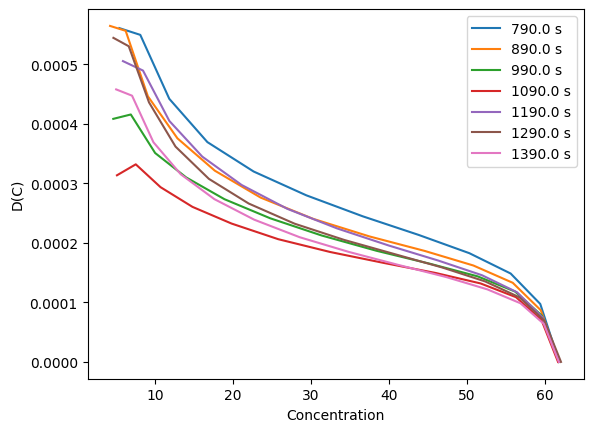

In [53]:
fig, ax = plt.subplots()
for i, (prof, d) in enumerate(zip(prof_trimmed, d_c)):
    if i > 0:
        ax.plot(prof, d, label = f"{times_bm[i]} s") 
ax.legend()
ax.set_xlabel("Concentration")
ax.set_ylabel("D(C)")

In [54]:
for list in d_c:
    print(list[1])

0.00011227634354646869
9.746108087642362e-05
8.689568893853312e-05
7.773237360408248e-05
7.097548477219551e-05
7.503273597740618e-05
6.939603102494476e-05
6.397352407860906e-05
